# Cell 01 - Load toàn bộ kết quả thực nghiệm cho báo cáo tổng hợp

## Mục tiêu cell này
Load lại các file kết quả quan trọng từ toàn bộ pipeline RAG.

## Vì sao cần làm bước này?
Từ file 03 đến file 10, ta đã tạo nhiều kết quả riêng lẻ:

- Corpus/chunk summary
- BM25 retrieval metrics
- Dense retrieval metrics
- Hybrid retrieval metrics
- Reranker retrieval metrics
- Corrective RAG behavior
- Generation quality

Notebook 11 sẽ gom các kết quả này thành một báo cáo tổng hợp để dùng cho:
- báo cáo đồ án/NCKH
- thuyết trình
- so sánh phương pháp
- chuẩn bị app/demo cuối

## Giải thích code
Code sẽ:
1. Khai báo các thư mục chính
2. Kiểm tra các file kết quả quan trọng
3. Load metric retrieval cuối cùng
4. Load summary Corrective RAG
5. Load summary Generation RAG
6. Hiển thị trạng thái file OK/MISSING

## Output mong đợi
Tất cả file quan trọng nên có trạng thái `OK`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

cwd = Path.cwd().resolve()
PROJECT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT / "data"
CHUNK_DIR = DATA_DIR / "chunks"
METRIC_DIR = PROJECT / "artifacts" / "metrics"
PRED_DIR = PROJECT / "artifacts" / "predictions"
PROMPT_DIR = PROJECT / "artifacts" / "prompts"
GEN_DIR = PROJECT / "artifacts" / "generation"
REPORT_DIR = PROJECT / "artifacts" / "reports"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

required_report_inputs = [
    CHUNK_DIR / "chunk_summary.csv",
    METRIC_DIR / "bm25_val_metrics.csv",
    METRIC_DIR / "dense_val_metrics.csv",
    METRIC_DIR / "retrieval_methods_val_comparison.csv",
    METRIC_DIR / "final_retrieval_val_comparison.csv",
    METRIC_DIR / "best_reranker_config.json",
    METRIC_DIR / "reranker_rag_summary.json",
    METRIC_DIR / "corrective_rag_summary.json",
    GEN_DIR / "generation_summary.json",
    GEN_DIR / "generation_quality_report.csv",
    GEN_DIR / "final_generation_outputs.csv",
    GEN_DIR / "final_generation_outputs.json"
]

input_check_df = pd.DataFrame([
    {
        "file": str(path.relative_to(PROJECT)),
        "status": "OK" if path.exists() else "MISSING",
        "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else 0
    }
    for path in required_report_inputs
])

chunk_summary_df = pd.read_csv(CHUNK_DIR / "chunk_summary.csv")
final_retrieval_df = pd.read_csv(METRIC_DIR / "final_retrieval_val_comparison.csv")
generation_quality_df = pd.read_csv(GEN_DIR / "generation_quality_report.csv")
final_generation_df = pd.read_csv(GEN_DIR / "final_generation_outputs.csv")

with open(METRIC_DIR / "best_reranker_config.json", "r", encoding="utf-8") as f:
    best_reranker_config = json.load(f)

with open(METRIC_DIR / "corrective_rag_summary.json", "r", encoding="utf-8") as f:
    corrective_summary = json.load(f)

with open(GEN_DIR / "generation_summary.json", "r", encoding="utf-8") as f:
    generation_summary = json.load(f)

print("Project:", PROJECT)
print("Report dir:", REPORT_DIR)

print("\nInput files:")
display(input_check_df)

print("\nChunk summary:")
display(chunk_summary_df)

print("\nFinal retrieval comparison:")
display(final_retrieval_df)

print("\nBest retriever:")
print(json.dumps(best_reranker_config, ensure_ascii=False, indent=2))

print("\nGeneration quality:")
display(generation_quality_df)

print("Tổng file OK:", (input_check_df["status"] == "OK").sum(), "/", len(input_check_df))

Project: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag
Report dir: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports

Input files:


,file,status,size_kb
0,data\chunks\chunk_summary.csv,OK,0.19
1,artifacts\metrics\bm25_val_metrics.csv,OK,0.22
2,artifacts\metrics\dense_val_metrics.csv,OK,0.24
3,artifacts\metrics\retrieval_methods_val_compar...,OK,0.47
4,artifacts\metrics\final_retrieval_val_comparis...,OK,0.49
5,artifacts\metrics\best_reranker_config.json,OK,0.51
6,artifacts\metrics\reranker_rag_summary.json,OK,1.20
7,artifacts\metrics\corrective_rag_summary.json,OK,3.45
8,artifacts\generation\generation_summary.json,OK,1.52
9,artifacts\generation\generation_quality_report...,OK,0.92



Chunk summary:


,source_type,num_chunks,num_parent_docs,avg_chunk_chars,min_chunk_chars,max_chunk_chars,languages
0,company_handbook,95,16,1038.95,128,1199,English
1,legal,91353,68663,746.39,4,1200,Vietnamese



Final retrieval comparison:


,metric,BM25,Dense_E5,Reranker,Weighted_Hybrid_RRF,reranker_minus_weighted_hybrid,reranker_vs_weighted_hybrid_percent
0,mrr,0.453844,0.540115,0.644133,0.541863,0.102270,18.873864
1,ndcg@10,0.497519,0.585338,0.676292,0.586727,0.089565,15.265286
2,recall@1,0.343754,0.421615,0.539686,0.422313,0.117374,27.793065
3,recall@10,0.687391,0.783614,0.834980,0.785125,0.049855,6.349911
4,recall@3,0.528995,0.624869,0.728646,0.625102,0.103544,16.564417
5,recall@5,0.605113,0.700407,0.784195,0.708077,0.076119,10.750041



Best retriever:
{
  "selected_by": "recall@5",
  "best_method": "Reranker",
  "best_value": 0.784195,
  "reason": "Reranker được chọn vì đạt Recall@5 cao nhất trên validation set và cải thiện rõ ràng so với Weighted Hybrid.",
  "pipeline": {
    "candidate_retriever": "Weighted_Hybrid_RRF",
    "reranker": "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
    "candidate_top_k": 30,
    "final_top_k": 5,
    "bm25_top_k": 50,
    "dense_top_k": 50,
    "bm25_weight": 0.7,
    "dense_weight": 1.3
  }
}

Generation quality:


,question,route,decision,should_call_llm,num_sources,num_evidence,overall_status,failed_checks,has_answer,has_sources,has_evidence,has_company_source,has_legal_source,has_legal_review_notice,mentions_85_percent,refuses_answer,asks_clarification
0,Nếu công ty áp dụng chính sách quản lý thiết b...,cross_policy,answer_with_legal_review_notice,True,6,3,PASS,[],True,True,True,True,True,True,NaN,NaN,NaN
1,What is the company policy for managing work d...,company_only,answer,True,5,3,PASS,[],True,True,True,True,NaN,NaN,NaN,NaN,NaN
2,Lương thử việc được quy định như thế nào?,legal_only,answer,True,5,3,PASS,[],True,True,True,NaN,True,NaN,True,NaN,NaN
3,Cách nấu phở bò ngon tại nhà như thế nào?,out_of_scope,refuse,False,0,0,PASS,[],True,True,True,NaN,NaN,NaN,NaN,True,NaN
4,Chính sách này áp dụng sao?,need_clarification,ask_clarification,False,0,0,PASS,[],True,True,True,NaN,NaN,NaN,NaN,NaN,True


Tổng file OK: 12 / 12


# Cell 02 - Tạo bảng so sánh Retrieval Methods cho báo cáo

## Mục tiêu cell này
Chuẩn hóa bảng so sánh các phương pháp retrieval để đưa vào báo cáo/thuyết trình.

## Vì sao cần làm bước này?
Bảng `final_retrieval_val_comparison.csv` hiện đã có đầy đủ metric, nhưng còn hơi thô.

Cell này sẽ tạo bảng báo cáo dễ đọc hơn, gồm:
- BM25
- Dense_E5
- Weighted_Hybrid_RRF
- Reranker
- phương pháp tốt nhất theo từng metric
- mức cải thiện của Reranker so với BM25, Dense và Weighted Hybrid

## Ý nghĩa
Bảng này dùng để chứng minh:
- BM25 là baseline từ khóa
- Dense_E5 tốt hơn BM25
- Weighted Hybrid cải thiện nhẹ so với Dense
- Reranker là phương pháp tốt nhất tổng thể

## Output mong đợi
Bạn cần thấy bảng report-ready và file được lưu vào `artifacts/reports`.

In [2]:
metric_order = ["recall@1", "recall@3", "recall@5", "recall@10", "mrr", "ndcg@10"]
method_cols = ["BM25", "Dense_E5", "Weighted_Hybrid_RRF", "Reranker"]

retrieval_report_df = final_retrieval_df.copy()
retrieval_report_df["metric"] = pd.Categorical(
    retrieval_report_df["metric"],
    categories=metric_order,
    ordered=True
)

retrieval_report_df = retrieval_report_df.sort_values("metric").reset_index(drop=True)

for method in method_cols:
    retrieval_report_df[f"reranker_minus_{method}"] = (
        retrieval_report_df["Reranker"] - retrieval_report_df[method]
    )

    retrieval_report_df[f"reranker_vs_{method}_percent"] = (
        retrieval_report_df[f"reranker_minus_{method}"] / retrieval_report_df[method] * 100
    )

retrieval_report_df["best_method"] = retrieval_report_df[method_cols].idxmax(axis=1)
retrieval_report_df["best_value"] = retrieval_report_df[method_cols].max(axis=1)

display_cols = [
    "metric",
    "BM25",
    "Dense_E5",
    "Weighted_Hybrid_RRF",
    "Reranker",
    "best_method",
    "best_value",
    "reranker_minus_BM25",
    "reranker_vs_BM25_percent",
    "reranker_minus_Dense_E5",
    "reranker_vs_Dense_E5_percent",
    "reranker_minus_Weighted_Hybrid_RRF",
    "reranker_vs_Weighted_Hybrid_RRF_percent"
]

retrieval_report_df = retrieval_report_df[display_cols]

round_cols = [col for col in retrieval_report_df.columns if col != "metric" and col != "best_method"]

for col in round_cols:
    retrieval_report_df[col] = retrieval_report_df[col].round(6)

retrieval_report_path = REPORT_DIR / "retrieval_methods_report_table.csv"
retrieval_report_df.to_csv(retrieval_report_path, index=False, encoding="utf-8-sig")

key_retrieval_findings = {
    "best_method_overall": "Reranker",
    "selected_metric": "recall@5",
    "reranker_recall@5": float(
        retrieval_report_df.loc[retrieval_report_df["metric"] == "recall@5", "Reranker"].iloc[0]
    ),
    "weighted_hybrid_recall@5": float(
        retrieval_report_df.loc[retrieval_report_df["metric"] == "recall@5", "Weighted_Hybrid_RRF"].iloc[0]
    ),
    "dense_recall@5": float(
        retrieval_report_df.loc[retrieval_report_df["metric"] == "recall@5", "Dense_E5"].iloc[0]
    ),
    "bm25_recall@5": float(
        retrieval_report_df.loc[retrieval_report_df["metric"] == "recall@5", "BM25"].iloc[0]
    ),
    "main_conclusion": "Reranker đạt kết quả tốt nhất trên toàn bộ metric retrieval, đặc biệt cải thiện Recall@5 so với Weighted Hybrid."
}

key_findings_path = REPORT_DIR / "retrieval_key_findings.json"

with open(key_findings_path, "w", encoding="utf-8") as f:
    json.dump(key_retrieval_findings, f, ensure_ascii=False, indent=2)

print("Đã lưu bảng retrieval report:", retrieval_report_path)
print("Đã lưu key findings:", key_findings_path)

display(retrieval_report_df)

print("\nKey findings:")
print(json.dumps(key_retrieval_findings, ensure_ascii=False, indent=2))

Đã lưu bảng retrieval report: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\retrieval_methods_report_table.csv
Đã lưu key findings: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\retrieval_key_findings.json


,metric,BM25,Dense_E5,Weighted_Hybrid_RRF,Reranker,best_method,best_value,reranker_minus_BM25,reranker_vs_BM25_percent,reranker_minus_Dense_E5,reranker_vs_Dense_E5_percent,reranker_minus_Weighted_Hybrid_RRF,reranker_vs_Weighted_Hybrid_RRF_percent
0,recall@1,0.343754,0.421615,0.422313,0.539686,Reranker,0.539686,0.195932,56.997737,0.118071,28.004459,0.117373,27.792893
1,recall@3,0.528995,0.624869,0.625102,0.728646,Reranker,0.728646,0.199651,37.741567,0.103777,16.607801,0.103544,16.564337
2,recall@5,0.605113,0.700407,0.708077,0.784195,Reranker,0.784195,0.179082,29.594803,0.083788,11.962759,0.076118,10.749961
3,recall@10,0.687391,0.783614,0.785125,0.834980,Reranker,0.834980,0.147589,21.470895,0.051366,6.555013,0.049855,6.349944
4,mrr,0.453844,0.540115,0.541863,0.644133,Reranker,0.644133,0.190289,41.928284,0.104018,19.258491,0.102270,18.873774
5,ndcg@10,0.497519,0.585338,0.586727,0.676292,Reranker,0.676292,0.178773,35.932899,0.090954,15.538714,0.089565,15.265191



Key findings:
{
  "best_method_overall": "Reranker",
  "selected_metric": "recall@5",
  "reranker_recall@5": 0.784195,
  "weighted_hybrid_recall@5": 0.708077,
  "dense_recall@5": 0.700407,
  "bm25_recall@5": 0.605113,
  "main_conclusion": "Reranker đạt kết quả tốt nhất trên toàn bộ metric retrieval, đặc biệt cải thiện Recall@5 so với Weighted Hybrid."
}


# Cell 03 - Vẽ biểu đồ so sánh Retrieval Methods

## Mục tiêu cell này
Tạo biểu đồ trực quan so sánh các phương pháp retrieval:
- BM25
- Dense_E5
- Weighted_Hybrid_RRF
- Reranker

## Vì sao cần làm bước này?
Bảng số liệu giúp báo cáo chính xác, nhưng biểu đồ giúp người đọc nhìn nhanh phương pháp nào tốt hơn.

Biểu đồ này sẽ thể hiện các metric quan trọng:
- Recall@1
- Recall@3
- Recall@5
- Recall@10
- MRR
- nDCG@10

## Ý nghĩa kỳ vọng
Reranker nên cao nhất ở toàn bộ metric, chứng minh bước rerank giúp cải thiện retrieval rõ ràng.

## Output mong đợi
Cell sẽ lưu biểu đồ vào:

`artifacts/reports/retrieval_methods_comparison.png`

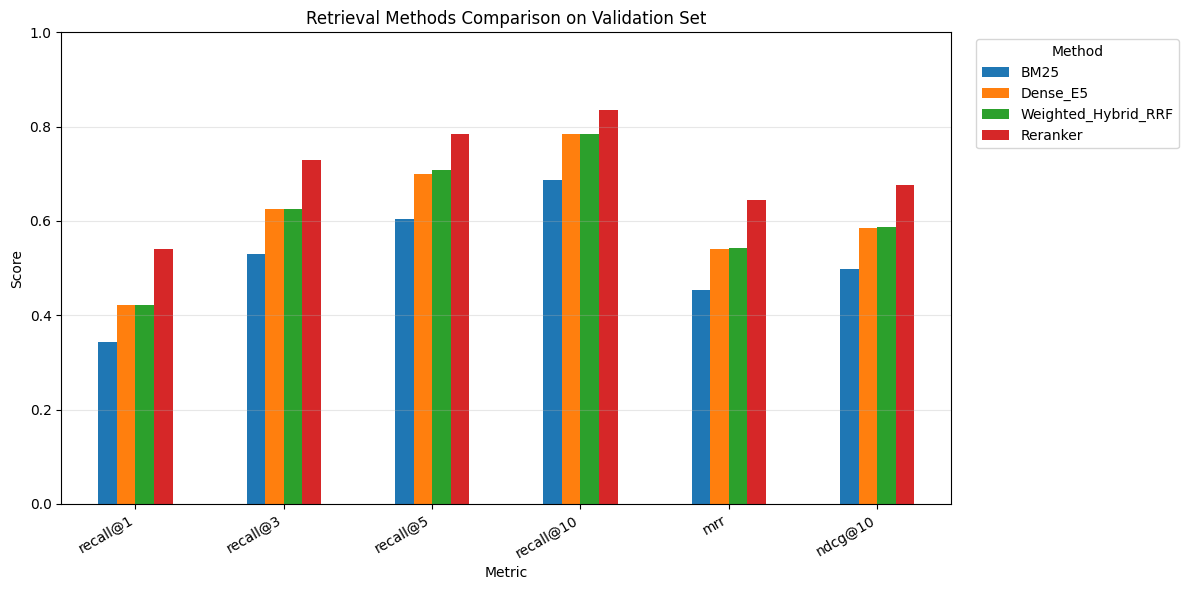

Đã lưu biểu đồ: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\retrieval_methods_comparison.png


In [3]:
import matplotlib.pyplot as plt

plot_df = retrieval_report_df[
    ["metric", "BM25", "Dense_E5", "Weighted_Hybrid_RRF", "Reranker"]
].copy()

plot_df = plot_df.set_index("metric")

ax = plot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("Retrieval Methods Comparison on Validation Set")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

retrieval_chart_path = REPORT_DIR / "retrieval_methods_comparison.png"
plt.savefig(retrieval_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ:", retrieval_chart_path)

# Cell 04 - Tạo bảng báo cáo Corrective RAG và Generation Quality

## Mục tiêu cell này
Tổng hợp hành vi của Corrective RAG và chất lượng câu trả lời Generation thành bảng báo cáo.

## Vì sao cần làm bước này?
Retrieval metrics chỉ cho biết hệ thống tìm tài liệu tốt hay không.  
Nhưng một hệ thống RAG doanh nghiệp còn cần chứng minh:

- Câu hỏi đúng phạm vi thì được trả lời.
- Câu hỏi ngoài phạm vi thì bị từ chối.
- Câu hỏi mơ hồ thì hệ thống hỏi lại.
- Câu hỏi liên quan pháp lý thì có cảnh báo HR/pháp chế.
- Câu trả lời cuối có nguồn và evidence.

Cell này sẽ gom các kết quả từ notebook 09 và 10 để tạo bảng báo cáo dễ đọc.

## Giải thích code
Code sẽ:
1. Tạo bảng behavior của Corrective RAG.
2. Tạo bảng quality của Generation.
3. Ghép answer preview từ final generation.
4. Lưu các bảng vào `artifacts/reports`.
5. Hiển thị bảng báo cáo cuối.

## Output mong đợi
Bạn cần thấy:
- Bảng Corrective RAG behavior.
- Bảng Generation quality.
- Tất cả case đều PASS.

In [4]:
corrective_behavior_df = generation_quality_df[
    [
        "question",
        "route",
        "decision",
        "should_call_llm",
        "num_sources",
        "num_evidence",
        "overall_status"
    ]
].copy()

answer_preview_df = final_generation_df[
    [
        "question",
        "answer"
    ]
].copy()

answer_preview_df["answer_preview"] = answer_preview_df["answer"].astype(str).str.slice(0, 280) + "..."
answer_preview_df = answer_preview_df.drop(columns=["answer"])

corrective_behavior_df = corrective_behavior_df.merge(
    answer_preview_df,
    on="question",
    how="left"
)

route_summary_df = (
    corrective_behavior_df["route"]
    .value_counts()
    .reset_index()
)

route_summary_df.columns = ["route", "count"]

decision_summary_df = (
    corrective_behavior_df["decision"]
    .value_counts()
    .reset_index()
)

decision_summary_df.columns = ["decision", "count"]

quality_summary = {
    "num_cases": int(len(corrective_behavior_df)),
    "num_pass": int((corrective_behavior_df["overall_status"] == "PASS").sum()),
    "num_fail": int((corrective_behavior_df["overall_status"] == "FAIL").sum()),
    "num_should_call_llm": int(corrective_behavior_df["should_call_llm"].sum()),
    "num_direct_response": int((~corrective_behavior_df["should_call_llm"]).sum())
}

corrective_behavior_path = REPORT_DIR / "corrective_rag_behavior_report.csv"
route_summary_path = REPORT_DIR / "corrective_route_summary.csv"
decision_summary_path = REPORT_DIR / "corrective_decision_summary.csv"
quality_summary_path = REPORT_DIR / "generation_quality_summary.json"

corrective_behavior_df.to_csv(corrective_behavior_path, index=False, encoding="utf-8-sig")
route_summary_df.to_csv(route_summary_path, index=False, encoding="utf-8-sig")
decision_summary_df.to_csv(decision_summary_path, index=False, encoding="utf-8-sig")

with open(quality_summary_path, "w", encoding="utf-8") as f:
    json.dump(quality_summary, f, ensure_ascii=False, indent=2)

print("Đã lưu Corrective behavior report:", corrective_behavior_path)
print("Đã lưu route summary:", route_summary_path)
print("Đã lưu decision summary:", decision_summary_path)
print("Đã lưu quality summary:", quality_summary_path)

print("\nCorrective RAG behavior report:")
display(corrective_behavior_df)

print("\nRoute summary:")
display(route_summary_df)

print("\nDecision summary:")
display(decision_summary_df)

print("\nGeneration quality summary:")
print(json.dumps(quality_summary, ensure_ascii=False, indent=2))

Đã lưu Corrective behavior report: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\corrective_rag_behavior_report.csv
Đã lưu route summary: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\corrective_route_summary.csv
Đã lưu decision summary: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\corrective_decision_summary.csv
Đã lưu quality summary: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\generation_quality_summary.json

Corrective RAG behavior report:


,question,route,decision,should_call_llm,num_sources,num_evidence,overall_status,answer_preview
0,Nếu công ty áp dụng chính sách quản lý thiết b...,cross_policy,answer_with_legal_review_notice,True,6,3,PASS,"Theo tài liệu nội bộ, công ty có chính sách qu..."
1,What is the company policy for managing work d...,company_only,answer,True,5,3,PASS,"Theo handbook nội bộ, công ty quản lý thiết bị..."
2,Lương thử việc được quy định như thế nào?,legal_only,answer,True,5,3,PASS,"Theo nguồn pháp luật được truy xuất, tiền lươn..."
3,Cách nấu phở bò ngon tại nhà như thế nào?,out_of_scope,refuse,False,0,0,PASS,Tôi chưa tìm thấy đủ thông tin phù hợp trong p...
4,Chính sách này áp dụng sao?,need_clarification,ask_clarification,False,0,0,PASS,Bạn vui lòng nói rõ hơn chính sách hoặc vấn đề...



Route summary:


,route,count
0,cross_policy,1
1,company_only,1
2,legal_only,1
3,out_of_scope,1
4,need_clarification,1



Decision summary:


,decision,count
0,answer,2
1,answer_with_legal_review_notice,1
2,refuse,1
3,ask_clarification,1



Generation quality summary:
{
  "num_cases": 5,
  "num_pass": 5,
  "num_fail": 0,
  "num_should_call_llm": 3,
  "num_direct_response": 2
}


# Cell 05 - Tạo báo cáo tổng hợp cuối cùng dạng Markdown

## Mục tiêu cell này
Tạo file báo cáo tổng hợp cuối cùng cho toàn bộ pipeline Enterprise Customer Support RAG.

## Vì sao cần làm bước này?
Các cell trước đã tạo nhiều bảng riêng lẻ:
- Corpus summary
- Retrieval comparison
- Corrective RAG behavior
- Generation quality

Cell này sẽ gom tất cả thành một file Markdown dễ đọc, dùng được cho:
- báo cáo đồ án
- thuyết trình
- tài liệu mô tả hệ thống
- README kết quả thực nghiệm

## Nội dung báo cáo
Báo cáo sẽ gồm:
1. Tổng quan dữ liệu
2. Pipeline hệ thống
3. So sánh Retrieval Methods
4. Kết luận best retriever
5. Corrective RAG behavior
6. Generation quality
7. Kết luận cuối

## Output mong đợi
File được lưu tại:

`artifacts/reports/final_evaluation_report.md`

In [5]:
def df_to_markdown(df):
    return df.to_markdown(index=False)


report_lines = []

report_lines.append("# Enterprise Customer Support RAG - Final Evaluation Report\n")

report_lines.append("## 1. Corpus Summary\n")
report_lines.append(
    "Hệ thống sử dụng hai nguồn dữ liệu chính: handbook nội bộ công ty và corpus pháp luật/tài liệu Việt Nam.\n"
)
report_lines.append(df_to_markdown(chunk_summary_df))
report_lines.append("\n")

report_lines.append("## 2. System Pipeline\n")
report_lines.append(
    """
Pipeline cuối cùng của hệ thống gồm các bước:

1. **Chunking & Corpus Building**: chuẩn hóa tài liệu thành các chunks.
2. **BM25 Retrieval**: tìm kiếm theo từ khóa.
3. **Dense Retrieval**: tìm kiếm theo ngữ nghĩa bằng multilingual embedding.
4. **Weighted Hybrid RRF**: kết hợp BM25 và Dense.
5. **Reranker**: đọc lại candidate chunks và xếp hạng lại.
6. **Corrective RAG**: quyết định trả lời, hỏi lại, cảnh báo hoặc từ chối.
7. **Generation**: tạo câu trả lời cuối cùng có nguồn và evidence.
"""
)

report_lines.append("## 3. Retrieval Methods Comparison\n")
report_lines.append(
    "Bảng dưới đây so sánh các phương pháp retrieval trên validation set.\n"
)
report_lines.append(df_to_markdown(retrieval_report_df))
report_lines.append("\n")

report_lines.append("## 4. Key Retrieval Findings\n")
report_lines.append(
    f"""
- Phương pháp tốt nhất tổng thể: **{key_retrieval_findings["best_method_overall"]}**
- Metric chọn chính: **{key_retrieval_findings["selected_metric"]}**
- BM25 Recall@5: **{key_retrieval_findings["bm25_recall@5"]:.6f}**
- Dense_E5 Recall@5: **{key_retrieval_findings["dense_recall@5"]:.6f}**
- Weighted Hybrid RRF Recall@5: **{key_retrieval_findings["weighted_hybrid_recall@5"]:.6f}**
- Reranker Recall@5: **{key_retrieval_findings["reranker_recall@5"]:.6f}**

Kết luận: {key_retrieval_findings["main_conclusion"]}
"""
)

report_lines.append("## 5. Corrective RAG Behavior\n")
report_lines.append(
    "Corrective RAG giúp hệ thống quyết định khi nào nên trả lời, khi nào nên hỏi lại hoặc từ chối.\n"
)
report_lines.append(df_to_markdown(corrective_behavior_df))
report_lines.append("\n")

report_lines.append("### Route Summary\n")
report_lines.append(df_to_markdown(route_summary_df))
report_lines.append("\n")

report_lines.append("### Decision Summary\n")
report_lines.append(df_to_markdown(decision_summary_df))
report_lines.append("\n")

report_lines.append("## 6. Generation Quality\n")
report_lines.append(
    f"""
Generation quality được kiểm tra bằng rule-based checks.

- Tổng số demo cases: **{quality_summary["num_cases"]}**
- PASS: **{quality_summary["num_pass"]}**
- FAIL: **{quality_summary["num_fail"]}**
- Số case gọi LLM / RAG prompt: **{quality_summary["num_should_call_llm"]}**
- Số case trả lời trực tiếp: **{quality_summary["num_direct_response"]}**
"""
)

report_lines.append(df_to_markdown(generation_quality_df))
report_lines.append("\n")

report_lines.append("## 7. Final Conclusion\n")
report_lines.append(
    """
Kết quả thực nghiệm cho thấy pipeline tốt nhất hiện tại là:

**Dense / BM25 Candidate Retrieval → Weighted Hybrid RRF → Reranker → Corrective RAG → Grounded Generation**

Trong đó, **Reranker** là retrieval method tốt nhất, đạt Recall@5 cao nhất trên validation set.  
Corrective RAG giúp hệ thống an toàn hơn bằng cách từ chối câu hỏi ngoài phạm vi, hỏi lại câu hỏi mơ hồ, và cảnh báo HR/pháp chế khi câu hỏi có yếu tố pháp lý.

Hệ thống cuối cùng có khả năng:
- Trả lời câu hỏi handbook nội bộ.
- Trả lời câu hỏi pháp luật/tài liệu Việt Nam.
- Đối chiếu chính sách nội bộ với bối cảnh Việt Nam.
- Hiển thị nguồn và evidence.
- Tránh trả lời khi câu hỏi ngoài phạm vi hoặc mơ hồ.
"""
)

final_report_text = "\n".join(report_lines)

final_report_path = REPORT_DIR / "final_evaluation_report.md"
final_report_path.write_text(final_report_text, encoding="utf-8")

print("Đã lưu final report:", final_report_path)
print("\nREPORT PREVIEW:")
print(final_report_text[:4000])

Đã lưu final report: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\final_evaluation_report.md

REPORT PREVIEW:
# Enterprise Customer Support RAG - Final Evaluation Report

## 1. Corpus Summary

Hệ thống sử dụng hai nguồn dữ liệu chính: handbook nội bộ công ty và corpus pháp luật/tài liệu Việt Nam.

| source_type      |   num_chunks |   num_parent_docs |   avg_chunk_chars |   min_chunk_chars |   max_chunk_chars | languages   |
|:-----------------|-------------:|------------------:|------------------:|------------------:|------------------:|:------------|
| company_handbook |           95 |                16 |           1038.95 |               128 |              1199 | English     |
| legal            |        91353 |             68663 |            746.39 |                 4 |              1200 | Vietnamese  |


## 2. System Pipeline


Pipeline cuối cùng của hệ thống gồm các bước:

1. **Chunking & Corpus Building**: chuẩn hóa t

# Cell 06 - Kiểm tra cuối notebook Evaluation Report

## Mục tiêu cell này
Kiểm tra toàn bộ file báo cáo đầu ra của notebook `11_evaluation_report.ipynb`.

## Vì sao cần làm bước này?
Notebook 11 có nhiệm vụ tổng hợp toàn bộ kết quả thực nghiệm thành báo cáo cuối.

Các file quan trọng cần có gồm:
- Bảng retrieval report
- Key findings
- Biểu đồ retrieval comparison
- Corrective RAG behavior report
- Route summary
- Decision summary
- Generation quality summary
- Final evaluation report Markdown

## Output mong đợi
Tất cả file cần có trạng thái `OK`.

In [6]:
required_report_files = [
    REPORT_DIR / "retrieval_methods_report_table.csv",
    REPORT_DIR / "retrieval_key_findings.json",
    REPORT_DIR / "retrieval_methods_comparison.png",
    REPORT_DIR / "corrective_rag_behavior_report.csv",
    REPORT_DIR / "corrective_route_summary.csv",
    REPORT_DIR / "corrective_decision_summary.csv",
    REPORT_DIR / "generation_quality_summary.json",
    REPORT_DIR / "final_evaluation_report.md"
]

report_check_df = pd.DataFrame([
    {
        "file": str(path.relative_to(PROJECT)),
        "status": "OK" if path.exists() else "MISSING",
        "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else 0
    }
    for path in required_report_files
])

final_report_text = (REPORT_DIR / "final_evaluation_report.md").read_text(encoding="utf-8")

report_summary = {
    "notebook": "11_evaluation_report.ipynb",
    "main_goal": "Summarize all RAG pipeline experiments into final evaluation report.",
    "best_retrieval_method": key_retrieval_findings["best_method_overall"],
    "selected_metric": key_retrieval_findings["selected_metric"],
    "reranker_recall@5": key_retrieval_findings["reranker_recall@5"],
    "weighted_hybrid_recall@5": key_retrieval_findings["weighted_hybrid_recall@5"],
    "generation_quality_pass": quality_summary["num_pass"],
    "generation_quality_total": quality_summary["num_cases"],
    "report_files_ok": int((report_check_df["status"] == "OK").sum()),
    "report_files_total": int(len(report_check_df)),
    "final_report_path": str(REPORT_DIR / "final_evaluation_report.md")
}

report_summary_path = REPORT_DIR / "evaluation_report_summary.json"

with open(report_summary_path, "w", encoding="utf-8") as f:
    json.dump(report_summary, f, ensure_ascii=False, indent=2)

report_check_df = pd.concat([
    report_check_df,
    pd.DataFrame([
        {
            "file": str(report_summary_path.relative_to(PROJECT)),
            "status": "OK" if report_summary_path.exists() else "MISSING",
            "size_kb": round(report_summary_path.stat().st_size / 1024, 2) if report_summary_path.exists() else 0
        }
    ])
], ignore_index=True)

print("Đã lưu report summary:", report_summary_path)

print("\nEvaluation report summary:")
print(json.dumps(report_summary, ensure_ascii=False, indent=2))

print("\nReport output files:")
display(report_check_df)

print("Tổng file OK:", (report_check_df["status"] == "OK").sum(), "/", len(report_check_df))

print("\nFinal report length:", len(final_report_text), "characters")
print("\nFinal report preview:")
print(final_report_text[:2000])

Đã lưu report summary: C:\Users\npd20\Downloads\Enterprise_Customer_Support_RAG\enterprise_customer_support_rag\artifacts\reports\evaluation_report_summary.json

Evaluation report summary:
{
  "notebook": "11_evaluation_report.ipynb",
  "main_goal": "Summarize all RAG pipeline experiments into final evaluation report.",
  "best_retrieval_method": "Reranker",
  "selected_metric": "recall@5",
  "reranker_recall@5": 0.784195,
  "weighted_hybrid_recall@5": 0.708077,
  "generation_quality_pass": 5,
  "generation_quality_total": 5,
  "report_files_ok": 8,
  "report_files_total": 8,
  "final_report_path": "C:\\Users\\npd20\\Downloads\\Enterprise_Customer_Support_RAG\\enterprise_customer_support_rag\\artifacts\\reports\\final_evaluation_report.md"
}

Report output files:


,file,status,size_kb
0,artifacts\reports\retrieval_methods_report_tab...,OK,0.94
1,artifacts\reports\retrieval_key_findings.json,OK,0.37
2,artifacts\reports\retrieval_methods_comparison...,OK,74.07
3,artifacts\reports\corrective_rag_behavior_repo...,OK,2.15
4,artifacts\reports\corrective_route_summary.csv,OK,0.10
5,artifacts\reports\corrective_decision_summary.csv,OK,0.09
6,artifacts\reports\generation_quality_summary.json,OK,0.11
7,artifacts\reports\final_evaluation_report.md,OK,13.07
8,artifacts\reports\evaluation_report_summary.json,OK,0.56


Tổng file OK: 9 / 9

Final report length: 12381 characters

Final report preview:
# Enterprise Customer Support RAG - Final Evaluation Report

## 1. Corpus Summary

Hệ thống sử dụng hai nguồn dữ liệu chính: handbook nội bộ công ty và corpus pháp luật/tài liệu Việt Nam.

| source_type      |   num_chunks |   num_parent_docs |   avg_chunk_chars |   min_chunk_chars |   max_chunk_chars | languages   |
|:-----------------|-------------:|------------------:|------------------:|------------------:|------------------:|:------------|
| company_handbook |           95 |                16 |           1038.95 |               128 |              1199 | English     |
| legal            |        91353 |             68663 |            746.39 |                 4 |              1200 | Vietnamese  |


## 2. System Pipeline


Pipeline cuối cùng của hệ thống gồm các bước:

1. **Chunking & Corpus Building**: chuẩn hóa tài liệu thành các chunks.
2. **BM25 Retrieval**: tìm kiếm theo từ khóa.
3. **Dense Retriev


## 1. File 11 làm gì?

File 11 là file **tổng hợp báo cáo thực nghiệm cuối cùng**.

Từ file 03 đến file 10, mình đã tạo nhiều kết quả riêng lẻ:

```text
file 03: tạo chunks/corpus
file 04: BM25 Retrieval
file 05: Dense Retrieval
file 07: Hybrid Retrieval
file 08: Reranker RAG
file 09: Corrective RAG
file 10: Generation RAG
```

File 11 gom tất cả lại thành:

```text
bảng so sánh
biểu đồ
báo cáo Markdown
kết luận cuối
```

Nói đơn giản:
**File 11 không train/tìm kiếm mới**, mà nó dùng lại kết quả đã lưu để viết báo cáo.

---

## 2. File 11 load những gì?

Cell 01 load các file quan trọng như:

```text
chunk_summary.csv
bm25_val_metrics.csv
dense_val_metrics.csv
retrieval_methods_val_comparison.csv
final_retrieval_val_comparison.csv
best_reranker_config.json
corrective_rag_summary.json
generation_summary.json
generation_quality_report.csv
final_generation_outputs.csv/json
```

Kết quả của bạn:

```text
Tổng file OK: 12 / 12
```

Nghĩa là toàn bộ output từ các notebook trước đều tồn tại đầy đủ.

---

## 3. Corpus summary nói gì?

Bảng corpus summary:

```text
company_handbook: 95 chunks, 16 docs, English
legal: 91,353 chunks, 68,663 docs, Vietnamese
```

Ý nghĩa:

```text
Nguồn nội bộ công ty nhỏ nhưng có cấu trúc rõ.
Nguồn legal rất lớn, cần retrieval/reranker mạnh để tìm đúng.
```

Đây là lý do đề tài cần BM25, Dense, Hybrid và Reranker.

---

## 4. File 11 so sánh retrieval methods

File 11 tạo bảng so sánh 4 phương pháp:

```text
BM25
Dense_E5
Weighted_Hybrid_RRF
Reranker
```

Kết quả quan trọng nhất:

```text
BM25 Recall@5              = 0.605113
Dense_E5 Recall@5          = 0.700407
Weighted Hybrid Recall@5   = 0.708077
Reranker Recall@5          = 0.784195
```

Kết luận:

```text
Reranker là phương pháp tốt nhất.
```

---

## 5. Vì sao chọn Recall@5?

Vì trong RAG, LLM thường chỉ đọc khoảng top 3 đến top 5 đoạn context.

Nếu tài liệu đúng nằm trong top 5 thì khả năng LLM trả lời đúng cao hơn.

Do đó file 11 ghi rõ:

```text
selected_metric = recall@5
best_method = Reranker
best_value = 0.784195
```

---

## 6. Biểu đồ ở file 11 có ý nghĩa gì?

Bạn đã vẽ biểu đồ:

```text
retrieval_methods_comparison.png
```

Biểu đồ cho thấy cột **Reranker** cao nhất ở tất cả metric:

```text
recall@1
recall@3
recall@5
recall@10
mrr
ndcg@10
```

Ý nghĩa khi thuyết trình:

```text
BM25 yếu nhất vì chỉ tìm theo từ khóa.
Dense tốt hơn vì hiểu ngữ nghĩa.
Weighted Hybrid cải thiện nhẹ.
Reranker tốt nhất vì đọc lại question + context và xếp hạng chính xác hơn.
```

---

## 7. Corrective RAG behavior report nói gì?

File 11 cũng tổng hợp kết quả từ file 09.

Bảng behavior có 5 case:

```text
cross_policy       → answer_with_legal_review_notice
company_only       → answer
legal_only         → answer
out_of_scope       → refuse
need_clarification → ask_clarification
```

Ý nghĩa:

```text
Hệ thống biết câu nào nên trả lời.
Hệ thống biết câu nào cần cảnh báo HR/pháp chế.
Hệ thống biết câu nào nên từ chối.
Hệ thống biết câu nào nên hỏi lại.
```

Đây là điểm mạnh của Corrective RAG.

---

## 8. Generation quality nói gì?

File 11 load kết quả từ file 10:

```text
num_cases = 5
num_pass = 5
num_fail = 0
num_should_call_llm = 3
num_direct_response = 2
```

Nghĩa là:

```text
3 câu được phép tạo RAG answer
2 câu không gọi LLM mà trả lời trực tiếp
toàn bộ 5 case đều PASS kiểm tra chất lượng
```

Các kiểm tra gồm:

```text
cross_policy có cả source nội bộ + legal không
cross_policy có cảnh báo HR/pháp chế không
legal_only có source legal không
lương thử việc có nhắc 85% không
out_of_scope có từ chối không
need_clarification có hỏi lại không
```

---

## 9. File 11 tạo báo cáo Markdown

File quan trọng nhất:

```text
artifacts/reports/final_evaluation_report.md
```

Báo cáo này gồm:

```text
1. Corpus Summary
2. System Pipeline
3. Retrieval Methods Comparison
4. Key Retrieval Findings
5. Corrective RAG Behavior
6. Generation Quality
7. Final Conclusion
```

Đây là file bạn có thể dùng để viết báo cáo hoặc copy vào phần kết quả thực nghiệm.

---

## 10. File 11 tạo những file nào?

Bạn đã tạo đủ:

```text
retrieval_methods_report_table.csv
retrieval_key_findings.json
retrieval_methods_comparison.png
corrective_rag_behavior_report.csv
corrective_route_summary.csv
corrective_decision_summary.csv
generation_quality_summary.json
final_evaluation_report.md
evaluation_report_summary.json
```

Kết quả cuối:

```text
Tổng file OK: 9 / 9
```

Nghĩa là notebook 11 hoàn tất.

---

## 11. Kết luận chính của file 11

File 11 chốt lại toàn bộ project hiện tại:

```text
Best retrieval method: Reranker
Selected metric: recall@5
Reranker Recall@5: 0.784195
Weighted Hybrid Recall@5: 0.708077
Generation quality: 5 / 5 PASS
```

Nói dễ hiểu:

```text
Reranker tìm tài liệu tốt nhất.
Corrective RAG giúp hệ thống trả lời an toàn hơn.
Generation tạo được answer có nguồn và evidence.
```

---

## 12. Vì sao file 12 là bước tiếp theo?

Sau file 11, mình đã có đầy đủ kết quả nghiên cứu và báo cáo.

File 12 nên làm:

```text
Streamlit App Demo
```

Tức là dựng giao diện để người dùng nhập câu hỏi và thấy:

```text
route
decision
answer
sources
evidence
quality/status
```

Nói ngắn gọn:

```text
File 11 tổng hợp kết quả để báo cáo.
File 12 biến pipeline thành app demo để trình bày/thử nghiệm.
```
